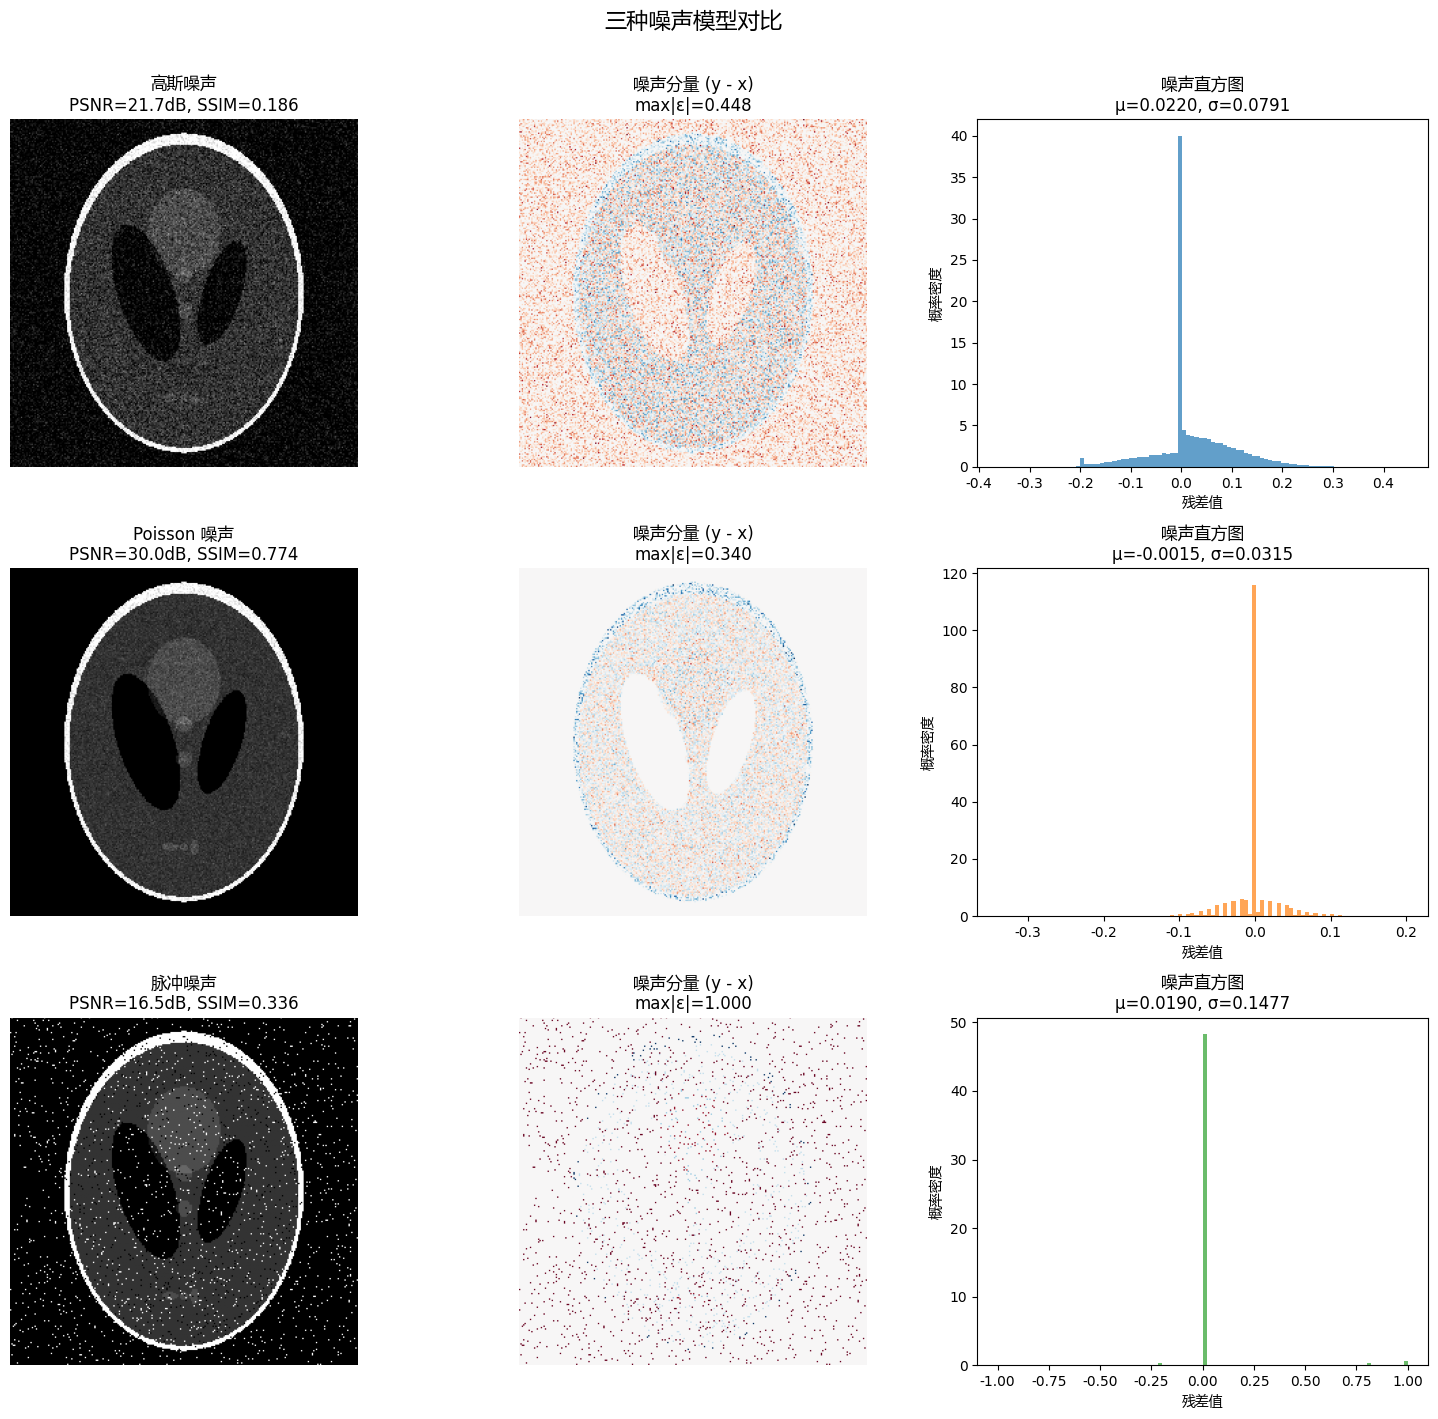

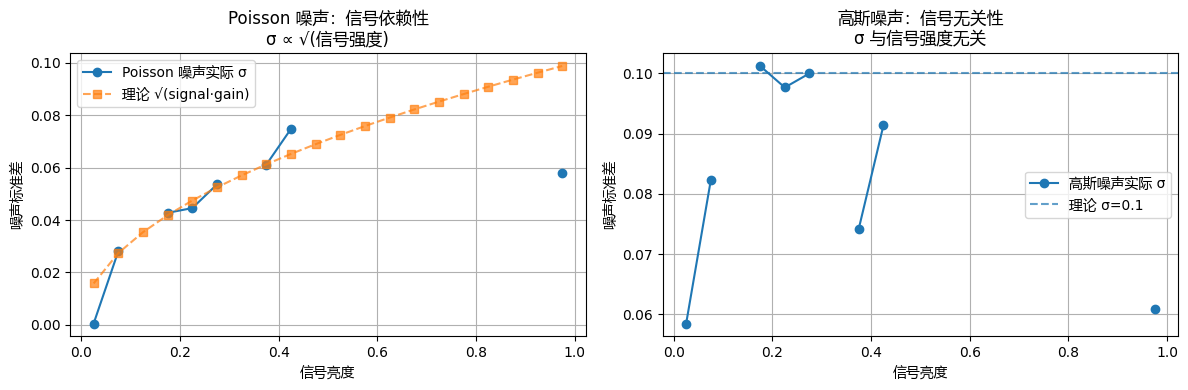

        噪声类型    PSNR(dB)      SSIM
------------------------------------
        高斯噪声       21.71    0.1856
  Poisson 噪声       30.01    0.7744
        脉冲噪声       16.54    0.3362


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import matplotlib as mpl

# ====== 解决中文乱码的核心代码 ======
plt.rcParams['font.family'] = ['DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================

np.random.seed(42)

# ---- 1. 加载图像（使用 Shepp-Logan 幻影，含亮区和暗区）----
n = 256
x = resize(shepp_logan_phantom(), (n, n), order=0, preserve_range=True, anti_aliasing=True)
x = x / x.max()  # 归一化到 [0, 1]

# ---- 2. 添加三种噪声 ----
# (a) 高斯噪声：ε ~ N(0, σ²I)，信号无关
sigma_gauss = 0.1
y_gauss = x + sigma_gauss * np.random.randn(n, n)
y_gauss = np.clip(y_gauss, 0, 1)

# (b) Poisson 噪声：y_i ~ Poisson((Ax)_i / gain) * gain，信号依赖
# 调节 gain 使 PSNR 与高斯噪声大致相当
gain = 0.01
y_poisson = np.random.poisson(x / gain).astype(np.float64) * gain
y_poisson = np.clip(y_poisson, 0, 1)

# (c) 脉冲噪声（椒盐噪声）：随机像素被替换为 0 或 1
amount_sp = 0.05
y_sp = random_noise(x, mode='s&p', amount=amount_sp)

# ---- 3. 计算质量度量 ----
psnr_gauss = peak_signal_noise_ratio(x, y_gauss)
psnr_poisson = peak_signal_noise_ratio(x, y_poisson)
psnr_sp = peak_signal_noise_ratio(x, y_sp)

ssim_gauss = structural_similarity(x, y_gauss, data_range=1.0)
ssim_poisson = structural_similarity(x, y_poisson, data_range=1.0)
ssim_sp = structural_similarity(x, y_sp, data_range=1.0)

# ---- 4. 可视化 ----
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
noisy_list = [y_gauss, y_poisson, y_sp]
names = ['高斯噪声', 'Poisson 噪声', '脉冲噪声']
psnrs = [psnr_gauss, psnr_poisson, psnr_sp]
ssims = [ssim_gauss, ssim_poisson, ssim_sp]

for i, (y, name) in enumerate(zip(noisy_list, names)):
    # 含噪图像
    axes[i, 0].imshow(y, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f'{name}\nPSNR={psnrs[i]:.1f}dB, SSIM={ssims[i]:.3f}')
    axes[i, 0].axis('off')

    # 噪声图像 = y - x
    noise = y - x
    vmax = max(np.abs(noise).max() * 0.8, 0.1)
    axes[i, 1].imshow(noise, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[i, 1].set_title(f'噪声分量 (y - x)\nmax|ε|={np.abs(noise).max():.3f}')
    axes[i, 1].axis('off')

    # 噪声直方图
    residual = (y - x).ravel()
    axes[i, 2].hist(residual, bins=100, density=True, alpha=0.7, color=f'C{i}')
    axes[i, 2].set_title(f'噪声直方图\nμ={residual.mean():.4f}, σ={residual.std():.4f}')
    axes[i, 2].set_xlabel('残差值')
    axes[i, 2].set_ylabel('概率密度')

plt.suptitle('三种噪声模型对比', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('实验1_3_噪声建模.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 5. Poisson 噪声的信号依赖性验证 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 将图像按亮度分桶，计算每桶的噪声标准差
n_bins = 20
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
noise_poisson = y_poisson - x
bin_stds = []
for j in range(n_bins):
    mask_bin = (x >= bin_edges[j]) & (x < bin_edges[j + 1])
    if mask_bin.sum() > 10:
        bin_stds.append(noise_poisson[mask_bin].std())
    else:
        bin_stds.append(np.nan)

axes[0].plot(bin_centers, bin_stds, 'o-', label='Poisson 噪声实际 σ')
axes[0].plot(bin_centers, np.sqrt(bin_centers * gain), 's--', label='理论 √(signal·gain)', alpha=0.7)
axes[0].set_xlabel('信号亮度')
axes[0].set_ylabel('噪声标准差')
axes[0].set_title('Poisson 噪声：信号依赖性\nσ ∝ √(信号强度)')
axes[0].legend()
axes[0].grid(True)

noise_gauss_map = y_gauss - x
bin_stds_g = []
for j in range(n_bins):
    mask_bin = (x >= bin_edges[j]) & (x < bin_edges[j + 1])
    if mask_bin.sum() > 10:
        bin_stds_g.append(noise_gauss_map[mask_bin].std())
    else:
        bin_stds_g.append(np.nan)

axes[1].plot(bin_centers, bin_stds_g, 'o-', label='高斯噪声实际 σ', color='C0')
axes[1].axhline(y=sigma_gauss, color='C0', linestyle='--', alpha=0.7, label=f'理论 σ={sigma_gauss}')
axes[1].set_xlabel('信号亮度')
axes[1].set_ylabel('噪声标准差')
axes[1].set_title('高斯噪声：信号无关性\nσ 与信号强度无关')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('实验1_3_噪声信号依赖性.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'噪声类型':>12s}  {'PSNR(dB)':>10s}  {'SSIM':>8s}")
print("-" * 36)
for name, psnr_val, ssim_val in zip(names, psnrs, ssims):
    print(f"{name:>12s}  {psnr_val:10.2f}  {ssim_val:8.4f}")